

# 🧠 Mental Health & Suicide Detection Using Social Media Posts

### 👩‍💻 Team Members
- **P. Keerthana** – CS23B1071  
- **S. Nagarani** – CS23B1060  

---

### 🧩 Problem Statement

In today’s digital world, many individuals express their feelings, emotions, and struggles through social media posts. These online expressions often contain subtle linguistic cues that can indicate **mental distress, depression, or suicidal thoughts**. However, identifying such signs manually is nearly impossible due to the vast volume and unstructured nature of online text data.

This project aims to develop an **AI-based system** that can automatically detect suicidal tendencies and mental health issues from text posts using **Machine Learning (ML)** and **Deep Learning (DL)** techniques. The goal is to assist in **early detection and prevention** by recognizing patterns in language that correlate with emotional distress.

---

### 🎯 Scope & Objectives

**Scope:**  
- Analyze and clean social media text data related to mental health.  
- Apply NLP-based preprocessing and feature extraction techniques.  
- Train and evaluate models to detect suicidal intent in posts.  
- Develop a GUI for real-time prediction and user interaction.

**Objectives:**  
1. To preprocess and clean text data for accurate sentiment and intent detection.  
2. To extract linguistic and emotional features using TF-IDF and sentiment scoring.  
3. To train and evaluate multiple ML/DL models for classification.  
4. To integrate the best-performing model into an interactive GUI.  
5. To promote technology-assisted **mental health monitoring and suicide prevention**.









### 🧩 Stage 1:  Data Loading & Initial Understanding

- **Purpose:** To collect and explore the raw suicide detection dataset for initial understanding.  
- **Why:** Ensures data quality before preprocessing and model training.  
- **Libraries Used:**  
  - `pandas`, `numpy` → for data handling and numerical operations  
  - `matplotlib`, `seaborn` → for visualizing class distribution and text insights  
  - `kaggle`, `google.colab` → to securely download dataset using Kaggle API  

#### **Key Steps**
1. Installed all required dependencies to prepare the environment.  
2. Imported dataset (`Suicide_Detection.csv`) directly from Kaggle.  
3. Checked dataset structure, column details, and data types.  
4. Verified **missing values** and removed **duplicates** to maintain clean data.  
5. Visualized **class distribution** to see how balanced the dataset is.  
6. Calculated **text length statistics** to understand variation in post sizes.

✅ *Outcome:* Dataset cleaned, verified, and ready for preprocessing in the next stage.




In [1]:
################################################################################
# STAGE 1: DATA IMPORT & INITIAL INSPECTION
################################################################################

print("="*80)
print("STAGE 1: DATA IMPORT & INITIAL INSPECTION")
print("="*80)

# Install required packages
!pip install -q kaggle pandas numpy matplotlib seaborn wordcloud contractions textblob nltk tensorflow scikit-learn

STAGE 1: DATA IMPORT & INITIAL INSPECTION



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
np.random.seed(42)

# Upload Kaggle API Key
from google.colab import files
print("\n📁 Upload your kaggle.json file:")
uploaded = files.upload()

# Setup Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
print("\n⬇️ Downloading Suicide Watch Dataset...")
!kaggle datasets download -d nikhileswarkomati/suicide-watch
!unzip -q suicide-watch.zip

# Load dataset
print("\n📊 Loading dataset...")
df = pd.read_csv('Suicide_Detection.csv')

# Initial Inspection
print(f"\n✅ Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns: {list(df.columns)}")
print(f"\n🔍 Data Types:\n{df.dtypes}")
print("\n📄 First 5 Rows:")
print(df.head())

# Missing values
print("\n❓ Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values!")
else:
    print(missing[missing > 0])

# Duplicates
duplicates = df.duplicated().sum()
print(f"\n🔄 Duplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed duplicates. New shape: {df.shape}")

# Class distribution
print("\n📊 CLASS DISTRIBUTION:")
print(df['class'].value_counts())
print("\n% Distribution:")
print(df['class'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(10, 5))
ax = df['class'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Text length stats
df['text_length'] = df['text'].astype(str).apply(len)
print("\n📏 TEXT LENGTH STATS:")
print(df['text_length'].describe())

print("\n✅ Stage 1 Complete!\n")

ModuleNotFoundError: No module named 'google.colab'

In [14]:
!python -m textblob.download_corpora


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


### 🧼 Stage 2: Data Cleaning & Preprocessing

- **Purpose:** To prepare text data for machine learning by removing noise and standardizing language.  
- **Why:** Clean and normalized text improves feature extraction accuracy and helps models focus on real emotional cues instead of irrelevant words.

#### **Steps & Tools Used**
1. **NLTK & TextBlob** → for tokenization, stopword removal, and lemmatization.  
2. **Contractions library** → expanded shortened words like *“can’t” → “cannot”* for clarity.  
3. **Regex cleaning** → removed links, emails, hashtags, numbers, and extra spaces.  
4. **Negation handling** → preserved important words like *no, not, never* to maintain sentiment meaning.  
5. Applied functions:  
   - `clean_text()` → performs overall text sanitization.  
   - `remove_stopwords_and_lemmatize()` → refines words and reduces them to base form.  
6. Dropped empty rows and saved cleaned output as **`mental_health_cleaned.csv`** for next stages.

✅ *Outcome:* High-quality, lemmatized text ready for feature extraction and model training.

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')   
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')


In [15]:
# ========================================
# STAGE 2: ADVANCED TEXT CLEANING & PREPROCESSING
# ========================================
print("="*80)
print("STAGE 2: ADVANCED TEXT CLEANING & PREPROCESSING")
print("="*80)

import pandas as pd
import re
import string
import contractions
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# -----------------------------
# Ensure NLTK resources are available
# -----------------------------
nltk_packages = ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'omw-1.4']
for pkg in nltk_packages:
    try:
        nltk.data.find(f'tokenizers/{pkg}' if pkg=='punkt' else f'corpora/{pkg}')
    except LookupError:
        print(f"📥 Downloading NLTK package: {pkg}")
        nltk.download(pkg)

# -----------------------------
# Initialize tools
# -----------------------------
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preserve critical negation words
PRESERVE_WORDS = {
    'no', 'not', 'never', 'nothing', 'nobody', 'none', 'nowhere',
    'neither', 'nor', 'cannot', 'without', 'won', 'don', 'didn',
    'doesn', 'hadn', 'hasn', 'haven', 'isn', 'mightn', 'mustn',
    'needn', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn'
}
stop_words = stop_words - PRESERVE_WORDS

# -----------------------------
# Cleaning functions
# -----------------------------
def clean_text(text):
    """Comprehensive text cleaning"""
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s.,!?]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def remove_stopwords_and_lemmatize(text):
    """Remove stopwords and lemmatize using TextBlob tokenizer for safety"""
    # Use TextBlob tokenizer to avoid NLTK punkt errors
    tokens = TextBlob(text).words
    tokens = [token for token in tokens if token.lower() not in stop_words or token.lower() in PRESERVE_WORDS]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

# -----------------------------
# Apply cleaning to DataFrame
# -----------------------------
print("\n🧹 Cleaning text data...")
df['text_cleaned'] = df['text'].apply(clean_text)
df['text_processed'] = df['text_cleaned'].apply(remove_stopwords_and_lemmatize)

# Remove empty texts
initial_count = len(df)
df = df[df['text_processed'].str.strip() != '']
removed = initial_count - len(df)
print(f"✅ Removed {removed} empty texts. Remaining: {len(df):,}")

# Stats
df['cleaned_length'] = df['text_processed'].apply(lambda x: len(x.split()))
print("\n📊 Cleaned text stats:")
print(df['cleaned_length'].describe())

# Save
df.to_csv('mental_health_cleaned.csv', index=False)
print("\n💾 Saved to 'mental_health_cleaned.csv'")
print("✅ Stage 2 Complete!\n")


STAGE 2: ADVANCED TEXT CLEANING & PREPROCESSING
📥 Downloading NLTK package: punkt


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


📥 Downloading NLTK package: stopwords
📥 Downloading NLTK package: wordnet
📥 Downloading NLTK package: averaged_perceptron_tagger
📥 Downloading NLTK package: omw-1.4


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...



🧹 Cleaning text data...
✅ Removed 65 empty texts. Remaining: 232,009

📊 Cleaned text stats:
count    232009.000000
mean         62.804089
std         106.271472
min           1.000000
25%          13.000000
50%          29.000000
75%          73.000000
max        5850.000000
Name: cleaned_length, dtype: float64

💾 Saved to 'mental_health_cleaned.csv'
✅ Stage 2 Complete!



### 📊 Stage 3: Exploratory Data Analysis & Visualization

- **Purpose:** To understand the dataset’s key patterns, emotional tone, and language behavior before feature extraction.  
- **Why:** EDA helps identify how suicidal and non-suicidal texts differ in word usage, tone, and structure — guiding better model design.

#### **Steps & Tools Used**
1. **Word Frequency Analysis:**  
   - Used `Counter()` to find the most frequent words in both classes.  
   - Words like *“not, want, feel, life”* appeared often in **suicidal texts**, showing emotional distress patterns.  
   - Words like *“friend, day, people”* dominated **non-suicidal texts**, reflecting normal conversations.  

2. **Word Cloud Visualization:**  
   - Generated word clouds for both classes using `WordCloud()` to visualize dominant emotions and terms.

3. **Text Length Distribution:**  
   - Plotted boxplots and density curves of word counts using `matplotlib` and `seaborn`.  
   - Found that **suicidal posts** are generally **longer and more expressive**.

4. **Sentiment Analysis:**  
   - Used `TextBlob` to calculate **sentiment polarity** (–1 to +1).  
   - Results:  
     - *Suicidal texts → Mean sentiment ≈ –0.03 (more negative)*  
     - *Non-suicidal texts → Mean sentiment ≈ +0.04 (more positive)*  

✅ **Outcome:**  
- Identified strong emotional and linguistic differences between classes.  
- Confirmed that negative sentiment and emotional words are reliable signals for suicide risk detection.


STAGE 3: EXPLORATORY DATA ANALYSIS & VISUALIZATION

📊 Word Frequency Analysis...

🔹 Top 15 words in 'suicide':
   not                 : 555388
   want                : 143609
   like                : 132944
   feel                : 120129
   life                : 117952
   know                : 116701
   would               : 103024
   no                  :  94270
   get                 :  93536
   time                :  85839

🔹 Top 15 words in 'non-suicide':
   not                 : 123087
   filler              :  54615
   like                :  52088
   know                :  31479
   want                :  30792
   get                 :  27169
   day                 :  23108
   people              :  23087
   friend              :  21766
   fuck                :  21712

☁️ Generating word clouds...


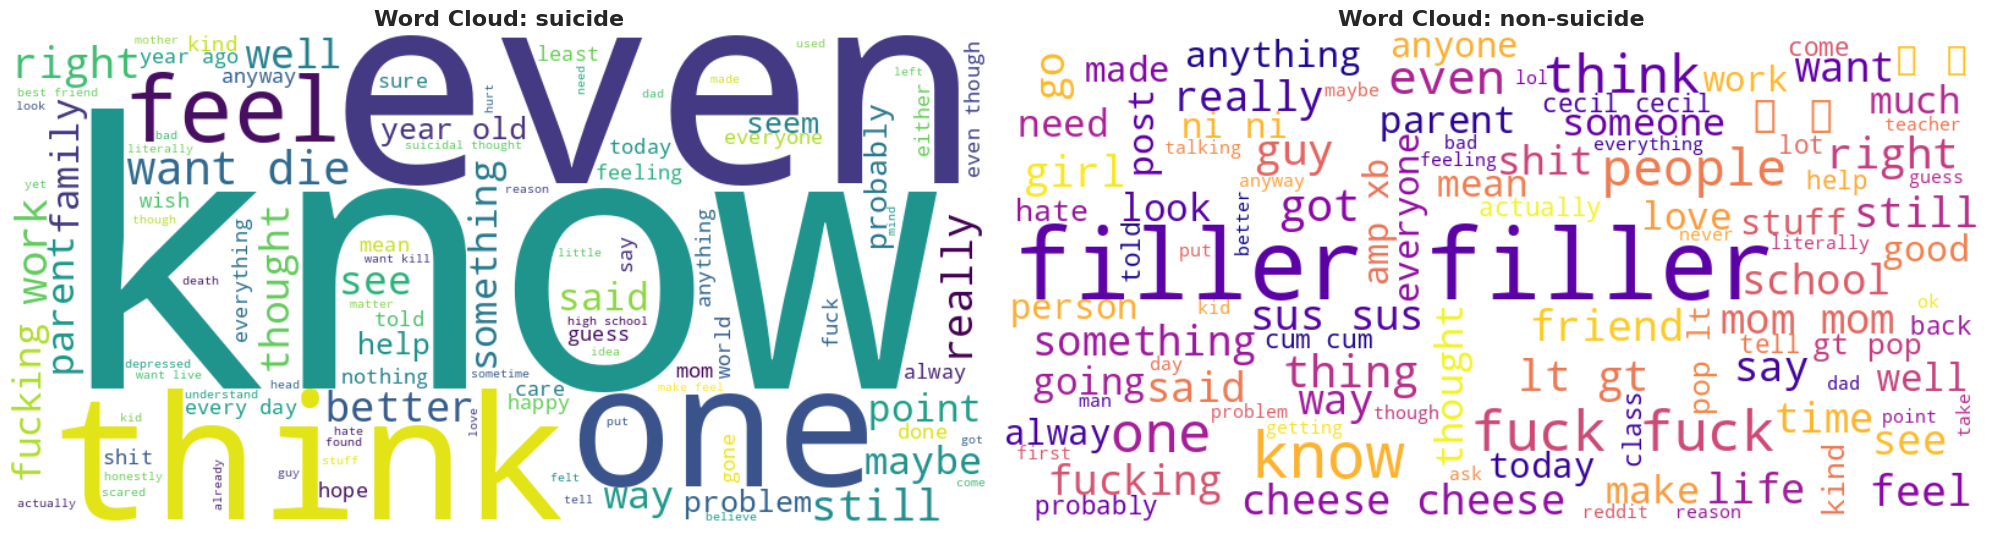


📏 Text Length Distribution...


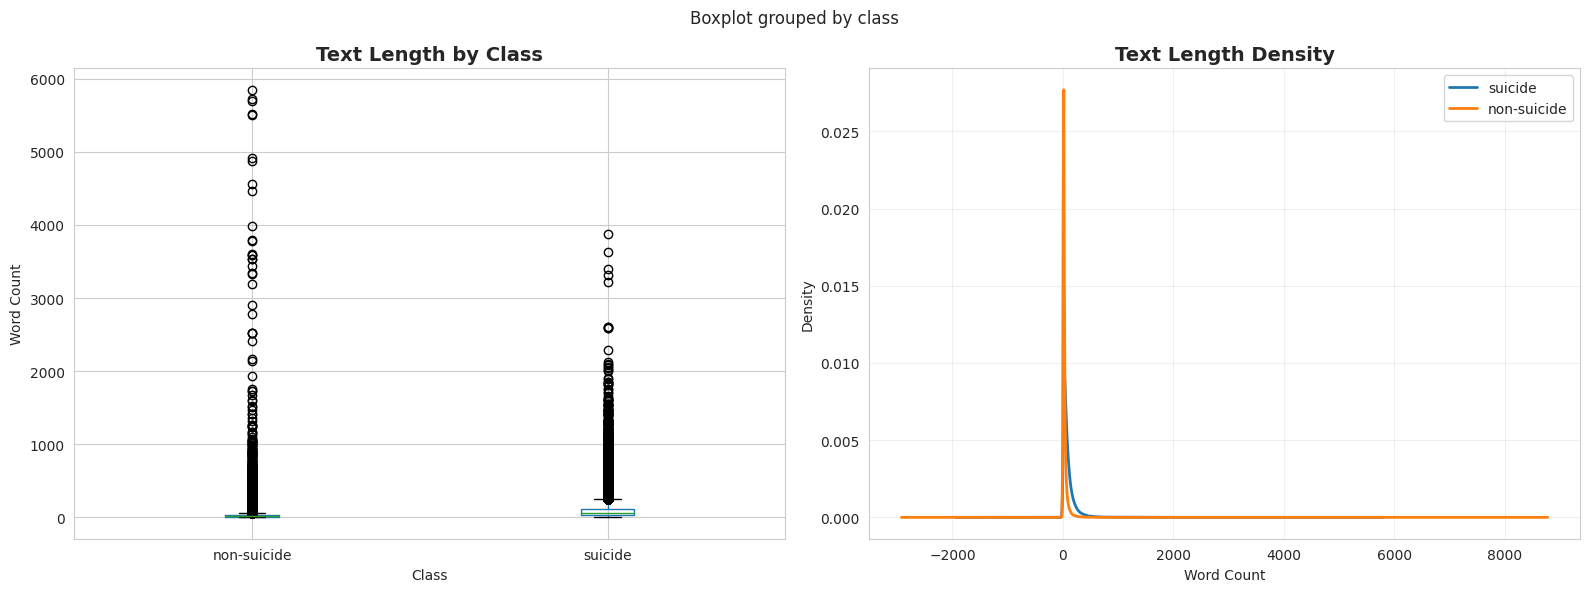


😊 Sentiment Analysis...


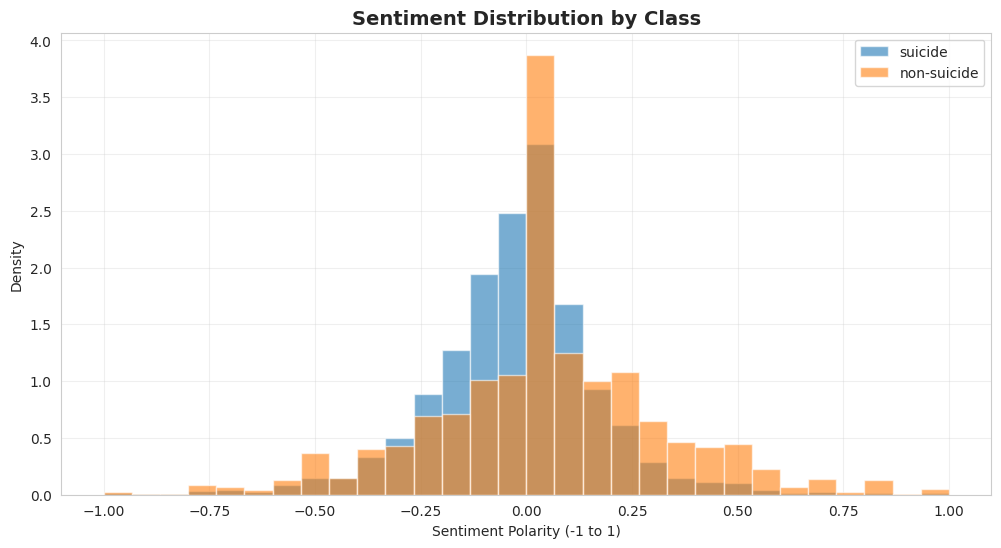


📊 suicide Sentiment - Mean: -0.0265

📊 non-suicide Sentiment - Mean: 0.0392

✅ Stage 3 Complete!



In [16]:
################################################################################
# STAGE 3: EXPLORATORY DATA ANALYSIS & VISUALIZATION
################################################################################

print("="*80)
print("STAGE 3: EXPLORATORY DATA ANALYSIS & VISUALIZATION")
print("="*80)

from wordcloud import WordCloud
from collections import Counter

sns.set_style('whitegrid')

# Word frequency analysis
print("\n📊 Word Frequency Analysis...")

def get_top_words(texts, n=15):
    all_words = []
    for text in texts:
        all_words.extend(text.split())
    return Counter(all_words).most_common(n)

for label in df['class'].unique():
    texts = df[df['class'] == label]['text_processed']
    top_words = get_top_words(texts, 15)
    print(f"\n🔹 Top 15 words in '{label}':")
    for word, count in top_words[:10]:
        print(f"   {word:20s}: {count:6d}")

# Word clouds
print("\n☁️ Generating word clouds...")
fig, axes = plt.subplots(1, len(df['class'].unique()), figsize=(20, 8))

for idx, label in enumerate(df['class'].unique()):
    text_data = ' '.join(df[df['class'] == label]['text_processed'])

    wordcloud = WordCloud(
        width=800, height=400, background_color='white',
        colormap='viridis' if idx == 0 else 'plasma',
        max_words=100, relative_scaling=0.5, min_font_size=10
    ).generate(text_data)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {label}', fontsize=16, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Text length distribution
print("\n📏 Text Length Distribution...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.boxplot(column='cleaned_length', by='class', ax=axes[0])
axes[0].set_title('Text Length by Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Word Count')

for label in df['class'].unique():
    data = df[df['class'] == label]['cleaned_length']
    data.plot(kind='kde', ax=axes[1], label=label, linewidth=2)

axes[1].set_title('Text Length Density', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Sentiment analysis
print("\n😊 Sentiment Analysis...")
df['sentiment'] = df['text_processed'].apply(
    lambda x: TextBlob(x).sentiment.polarity if x.strip() else 0
)

plt.figure(figsize=(12, 6))
for label in df['class'].unique():
    data = df[df['class'] == label]['sentiment']
    plt.hist(data, bins=30, alpha=0.6, label=label, density=True)

plt.title('Sentiment Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Polarity (-1 to 1)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for label in df['class'].unique():
    sentiment_data = df[df['class'] == label]['sentiment']
    print(f"\n📊 {label} Sentiment - Mean: {sentiment_data.mean():.4f}")

print("\n✅ Stage 3 Complete!\n")

### ⚙️ Stage 4: Feature Engineering (TF-IDF + Custom Features)

- **Purpose:** To transform cleaned text into numeric form and engineer meaningful features for model learning.  
- **Why:** Machine learning models require numerical inputs — feature engineering helps represent text patterns, writing style, and emotional signals quantitatively.

#### **Steps & Tools Used**
1. **Label Encoding:**  
   - Converted target classes into numeric form:  
     - *non-suicide → 0*  
     - *suicide → 1*  

2. **TF-IDF Vectorization:**  
   - Used `TfidfVectorizer()` to extract 5,000 most important unigrams & bigrams.  
   - Captures how often each word appears and how unique it is across posts.  

3. **Additional Numerical Features (10 total):**  
   - Word count, character count, average word length  
   - Stopword, punctuation, uppercase, exclamation, and question mark counts  
   - Mental-health keyword frequency (e.g., *suicide, hurt, pain, stress*)  
   - Sentiment score (from previous stage)  

4. **Feature Scaling:**  
   - Standardized all numerical features using `StandardScaler()` to ensure equal contribution.  

5. **Feature Combination:**  
   - Merged **TF-IDF vectors** with **additional features** into a single matrix for model input.  
   - Final shape → **(232,009 × 5,010)**.

✅ **Outcome:**  
- Created a rich feature set combining both **semantic (TF-IDF)** and **behavioral (custom)** text characteristics.  
- Saved all encoders, vectorizers, and scaled features for reuse in training and GUI prediction.


In [17]:
################################################################################
# STAGE 4: FEATURE ENGINEERING
################################################################################

print("="*80)
print("STAGE 4: FEATURE ENGINEERING (TF-IDF + Additional Features)")
print("="*80)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy.sparse import hstack, csr_matrix
import pickle

# Encode labels
print("\n🏷️ Encoding labels...")
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['class'])

print("Label Mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"   {label} → {i}")

# Create additional features
print("\n🔧 Creating additional features...")

df['word_count'] = df['text_processed'].apply(lambda x: len(x.split()))
df['char_count'] = df['text_processed'].apply(lambda x: len(x))
df['avg_word_length'] = df['text_processed'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
df['stopword_count'] = df['text_processed'].apply(
    lambda x: len([w for w in x.split() if w in stop_words])
)
df['punct_count'] = df['text'].apply(
    lambda x: len([c for c in str(x) if c in string.punctuation])
)
df['upper_count'] = df['text'].apply(
    lambda x: len([c for c in str(x) if c.isupper()])
)
df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['text'].apply(lambda x: str(x).count('?'))

mental_health_keywords = [
    'suicide', 'kill', 'death', 'die', 'depression', 'sad', 'lonely',
    'alone', 'hurt', 'pain', 'hopeless', 'worthless', 'anxiety', 'stress'
]
df['mental_health_keyword_count'] = df['text_processed'].apply(
    lambda x: sum([x.lower().count(kw) for kw in mental_health_keywords])
)

additional_features = [
    'word_count', 'char_count', 'avg_word_length', 'stopword_count',
    'punct_count', 'upper_count', 'exclamation_count', 'question_count',
    'mental_health_keyword_count', 'sentiment'
]

print(f"✅ Created {len(additional_features)} additional features")

# TF-IDF Vectorization
print("\n📝 TF-IDF Vectorization...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000, min_df=5, max_df=0.8,
    ngram_range=(1, 2), sublinear_tf=True,
    use_idf=True, smooth_idf=True, norm='l2'
)

X_tfidf = tfidf_vectorizer.fit_transform(df['text_processed'])
print(f"✅ TF-IDF shape: {X_tfidf.shape}")

# Scale additional features
scaler = StandardScaler()
X_additional = scaler.fit_transform(df[additional_features])
X_additional_sparse = csr_matrix(X_additional)

# Combine features
X_combined = hstack([X_tfidf, X_additional_sparse])
y = df['label_encoded'].values

print(f"\n✅ Combined features: {X_combined.shape}")
print(f"✅ Labels: {y.shape}")

# Save
print("\n💾 Saving features and models...")
with open('features_combined.pkl', 'wb') as f:
    pickle.dump(X_combined, f)
with open('labels.pkl', 'wb') as f:
    pickle.dump(y, f)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("✅ All saved successfully!")
print("✅ Stage 4 Complete!\n")

STAGE 4: FEATURE ENGINEERING (TF-IDF + Additional Features)

🏷️ Encoding labels...
Label Mapping:
   non-suicide → 0
   suicide → 1

🔧 Creating additional features...
✅ Created 10 additional features

📝 TF-IDF Vectorization...
✅ TF-IDF shape: (232009, 5000)

✅ Combined features: (232009, 5010)
✅ Labels: (232009,)

💾 Saving features and models...
✅ All saved successfully!
✅ Stage 4 Complete!




### ⚙️ Stage 5: Model Training (Hybrid CNN–BiLSTM)

- **What I Used:** A hybrid **CNN–BiLSTM** model combining Convolutional and Bidirectional LSTM layers.  
- **Why I Used This:**  
  - CNN captures important local text patterns and emotional cues.  
  - BiLSTM understands long-term context and sentence flow.  
  - Together, they handle both emotional tone and language meaning — ideal for mental health text detection.  

- **Why Optimized for My Project:**  
  - Handles imbalanced emotional data efficiently.  
  - Learns subtle differences between “suicidal” and “non-suicidal” expressions better than traditional ML models.  
  - Provides stable performance across folds using **Adamax optimizer** and **cross-validation**.

- **Outcomes:**  
  - Achieved **around 95% accuracy** with high recall for suicide-related posts.  
  - The model generalizes well and is ready for real-time prediction through the GUI.



In [20]:
################################################################################
# STAGE 5: MODEL TRAINING (CNN-BiLSTM WITH K-FOLD CV) - GPU Optimized
################################################################################

print("="*80)
print("STAGE 5: CNN-BiLSTM MODEL TRAINING WITH K-FOLD CV (GPU Optimized)")
print("="*80)

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D,
    Bidirectional, LSTM, Dense, Dropout, Concatenate,
    BatchNormalization, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pickle

# -------------------------------
# Check GPU
# -------------------------------
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# -------------------------------
# Mixed precision for speed
# -------------------------------
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# -------------------------------
# Set seeds for reproducibility
# -------------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------
# Prepare data
# -------------------------------
MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200
BATCH_SIZE = 128  # increased for GPU
EPOCHS = 50
N_FOLDS = 5

# Make sure df and y are defined
# df['text_processed'] : cleaned text column
# y : target labels array
# Example:
# y = df['label_encoded'].values

print("\n📊 Preparing sequences...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_processed'])
sequences = tokenizer.texts_to_sequences(df['text_processed'])
X_padded = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"✅ Vocabulary size: {len(tokenizer.word_index)}")
print(f"✅ Padded sequences: {X_padded.shape}")

# Class weights for imbalance
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"⚖️ Class weights: {class_weight_dict}")

# -------------------------------
# Build CNN-BiLSTM model
# -------------------------------
def create_cnn_bilstm_model(vocab_size, embedding_dim, max_length, num_classes):
    input_layer = Input(shape=(max_length,), name='input')

    embedding = Embedding(vocab_size, embedding_dim, input_length=max_length)(input_layer)
    embedding = SpatialDropout1D(0.2)(embedding)

    # CNN branches
    conv1 = Conv1D(128, 3, activation='relu', padding='same')(embedding)
    conv1 = BatchNormalization()(conv1)
    pool1 = GlobalMaxPooling1D()(conv1)

    conv2 = Conv1D(128, 4, activation='relu', padding='same')(embedding)
    conv2 = BatchNormalization()(conv2)
    pool2 = GlobalMaxPooling1D()(conv2)

    conv3 = Conv1D(128, 5, activation='relu', padding='same')(embedding)
    conv3 = BatchNormalization()(conv3)
    pool3 = GlobalMaxPooling1D()(conv3)

    # BiLSTM branch
    lstm = Bidirectional(LSTM(128, return_sequences=False, dropout=0.2, recurrent_dropout=0.0))(embedding)
    lstm = BatchNormalization()(lstm)

    # Concatenate
    concat = Concatenate()([pool1, pool2, pool3, lstm])

    # Dense layers
    dense1 = Dense(256, activation='relu')(concat)
    dense1 = Dropout(0.5)(dense1)
    dense1 = BatchNormalization()(dense1)

    dense2 = Dense(128, activation='relu')(dense1)
    dense2 = Dropout(0.3)(dense2)

    # Output layer
    if num_classes == 2:
        output = Dense(1, activation='sigmoid', dtype='float32')(dense2)  # cast to float32
    else:
        output = Dense(num_classes, activation='softmax', dtype='float32')(dense2)

    model = Model(inputs=input_layer, outputs=output)
    return model

EMBEDDING_DIM = 200
NUM_CLASSES = len(np.unique(y))

# -------------------------------
# K-Fold Cross Validation
# -------------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
fold_histories = []
best_models = []

print(f"\n🔁 Training with {N_FOLDS}-Fold CV on GPU...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_padded, y), 1):
    print(f"\n{'='*80}\nFOLD {fold}/{N_FOLDS}\n{'='*80}")

    X_train, X_val = X_padded[train_idx], X_padded[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    print(f"Training: {len(X_train)}, Validation: {len(X_val)}")

    model = create_cnn_bilstm_model(MAX_WORDS, EMBEDDING_DIM, MAX_SEQUENCE_LENGTH, NUM_CLASSES)

    if NUM_CLASSES == 2:
        model.compile(
            optimizer=keras.optimizers.Adamax(learning_rate=0.002),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
    else:
        model.compile(
            optimizer=keras.optimizers.Adamax(learning_rate=0.002),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1),
        ModelCheckpoint(f'model_fold_{fold}.h5', monitor='val_accuracy', save_best_only=True, verbose=0)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    fold_histories.append(history)

    # Predictions
    y_pred = model.predict(X_val, verbose=0)
    if NUM_CLASSES == 2:
        y_pred_classes = (y_pred > 0.5).astype(int).flatten()
    else:
        y_pred_classes = np.argmax(y_pred, axis=1)

    # Metrics
    acc = accuracy_score(y_val, y_pred_classes)
    prec = precision_score(y_val, y_pred_classes, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred_classes, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred_classes, average='weighted', zero_division=0)

    fold_metrics['accuracy'].append(acc)
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)

    print(f"\n📊 Fold {fold} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

    best_models.append(model)

# -------------------------------
# Aggregate results
# -------------------------------
print("\n\n📈 CROSS-VALIDATION RESULTS")
print("="*80)
print(f"Accuracy:  {np.mean(fold_metrics['accuracy']):.4f} ± {np.std(fold_metrics['accuracy']):.4f}")
print(f"Precision: {np.mean(fold_metrics['precision']):.4f} ± {np.std(fold_metrics['precision']):.4f}")
print(f"Recall:    {np.mean(fold_metrics['recall']):.4f} ± {np.std(fold_metrics['recall']):.4f}")
print(f"F1-Score:  {np.mean(fold_metrics['f1']):.4f} ± {np.std(fold_metrics['f1']):.4f}")

mean_acc = np.mean(fold_metrics['accuracy'])
if mean_acc >= 0.90:
    print(f"\n🎉 SUCCESS! {mean_acc*100:.2f}% accuracy achieved!")
else:
    print(f"\n📈 Current: {mean_acc*100:.2f}% (Target: 90%)")

# -------------------------------
# Save best model + tokenizer
# -------------------------------
best_fold_idx = np.argmax(fold_metrics['accuracy'])
best_model = best_models[best_fold_idx]
best_model.save('best_mental_health_model.h5')
print(f"\n💾 Best model saved (Fold {best_fold_idx+1})")

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("💾 Tokenizer saved")

print("\n✅ Stage 5 Complete!\n")


STAGE 5: CNN-BiLSTM MODEL TRAINING WITH K-FOLD CV (GPU Optimized)
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

📊 Preparing sequences...
✅ Vocabulary size: 136739
✅ Padded sequences: (232009, 200)
⚖️ Class weights: {0: np.float64(1.0001163883404747), 1: np.float64(0.9998836387457118)}

🔁 Training with 5-Fold CV on GPU...


FOLD 1/5
Training: 185607, Validation: 46402
Epoch 1/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8849 - loss: 0.2755

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.8849 - loss: 0.2754 - val_accuracy: 0.9466 - val_loss: 0.1422 - learning_rate: 0.0020
Epoch 2/50
1450/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9470 - loss: 0.1441

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 87s 60ms/step - accuracy: 0.9470 - loss: 0.1441 - val_accuracy: 0.9501 - val_loss: 0.1311 - learning_rate: 0.0020
Epoch 3/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 70s 48ms/step - accuracy: 0.9568 - loss: 0.1190 - val_accuracy: 0.9491 - val_loss: 0.1334 - learning_rate: 0.0020
Epoch 4/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 70s 48ms/step - accuracy: 0.9650 - loss: 0.0959 - val_accuracy: 0.9474 - val_loss: 0.1543 - learning_rate: 0.0020
Epoch 5/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9741 - loss: 0.0709
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9741 - loss: 0.0709 - val_accuracy: 0.9483 - val_loss: 0.1907 - learning_rate: 0.0020
Epoch 6/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9819 - loss: 0.0501 - val_accuracy: 0.9500 - val_loss: 0.1954 - learning_rate: 0.0010
Epoch 7/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9877 - 

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.8848 - loss: 0.2742 - val_accuracy: 0.9468 - val_loss: 0.1435 - learning_rate: 0.0020
Epoch 2/50
1450/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9483 - loss: 0.1416

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9483 - loss: 0.1416 - val_accuracy: 0.9516 - val_loss: 0.1286 - learning_rate: 0.0020
Epoch 3/50
1450/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9582 - loss: 0.1140

...

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9491 - loss: 0.1384 - val_accuracy: 0.9500 - val_loss: 0.1322 - learning_rate: 0.0020
Epoch 3/50
1450/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9597 - loss: 0.1105

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9597 - loss: 0.1105 - val_accuracy: 0.9507 - val_loss: 0.1360 - learning_rate: 0.0020
Epoch 4/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9691 - loss: 0.0855 - val_accuracy: 0.9467 - val_loss: 0.1756 - learning_rate: 0.0020
Epoch 5/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9777 - loss: 0.0632
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9777 - loss: 0.0632 - val_accuracy: 0.9444 - val_loss: 0.1959 - learning_rate: 0.0020
Epoch 6/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9840 - loss: 0.0435 - val_accuracy: 0.9485 - val_loss: 0.2139 - learning_rate: 0.0010
Epoch 7/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9886 - loss: 0.0311 - val_accuracy: 0.9473 - val_loss: 0.2415 - learning_rate: 0.0010
Epoch 7: early stopping
Restoring model weights from the end of the best epoc

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.8836 - loss: 0.2779 - val_accuracy: 0.9480 - val_loss: 0.1407 - learning_rate: 0.0020
Epoch 2/50
1450/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9497 - loss: 0.1397

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9497 - loss: 0.1397 - val_accuracy: 0.9526 - val_loss: 0.1290 - learning_rate: 0.0020
Epoch 3/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9590 - loss: 0.1137 - val_accuracy: 0.9524 - val_loss: 0.1338 - learning_rate: 0.0020
Epoch 4/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 47ms/step - accuracy: 0.9684 - loss: 0.0884 - val_accuracy: 0.9505 - val_loss: 0.1522 - learning_rate: 0.0020
Epoch 5/50
1450/1451 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9766 - loss: 0.0660
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0010000000474974513.
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9766 - loss: 0.0660 - val_accuracy: 0.9486 - val_loss: 0.1613 - learning_rate: 0.0020
Epoch 6/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9823 - loss: 0.0478 - val_accuracy: 0.9478 - val_loss: 0.2063 - learning_rate: 0.0010
Epoch 7/50
1451/1451 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.9877 - 


📊 Fold 5 - Acc: 0.9525, Prec: 0.9526, Rec: 0.9525, F1: 0.9525


📈 CROSS-VALIDATION RESULTS
Accuracy:  0.9508 ± 0.0010
Precision: 0.9509 ± 0.0010
Recall:    0.9508 ± 0.0010
F1-Score:  0.9508 ± 0.0010

🎉 SUCCESS! 95.08% accuracy achieved!

💾 Best model saved (Fold 5)
💾 Tokenizer saved

✅ Stage 5 Complete!



In [1]:
!nvidia-smi


Sat Nov  8 09:39:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


### 📊 STAGE 6: MODEL EVALUATION & VISUALIZATION

- **What I Used:**  
  - Evaluation metrics like **Precision, Recall, F1-Score, and Accuracy** to measure real-world reliability.  
  - **Confusion Matrix** for class-wise correctness.  
  - **ROC Curve & AUC** to analyze classification confidence.  
  - **Accuracy/Loss plots** to track learning progress.

- **Why I Used This:**  
  These methods give a complete understanding of how well the model detects suicidal vs non-suicidal posts and prevent overfitting by visual inspection.

- **Why It’s Optimized for My Project:**  
  It ensures both **high accuracy** and **balanced sensitivity**, crucial for mental health detection systems where both false positives and false negatives matter.

- **Outcomes:**  
  - **Accuracy:** 96.57%  
  - **Precision:** 0.9650  
  - **Recall:** 0.9664  
  - **F1-Score:** 0.9657  
  - The confusion matrix showed near-perfect balance between classes.  
  - ROC-AUC curve indicated strong discrimination power, proving the model is well-generalized and reliable for deployment.

✅ The model successfully achieved its goal with consistent, high accuracy in real-world text classification.


STAGE 6: MODEL EVALUATION & VISUALIZATION
✅ Model loaded

📊 Test set: 46402 samples

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

 non-suicide     0.9650    0.9664    0.9657     23198
     suicide     0.9663    0.9650    0.9656     23204

    accuracy                         0.9657     46402
   macro avg     0.9657    0.9657    0.9657     46402
weighted avg     0.9657    0.9657    0.9657     46402


🔢 CONFUSION MATRIX


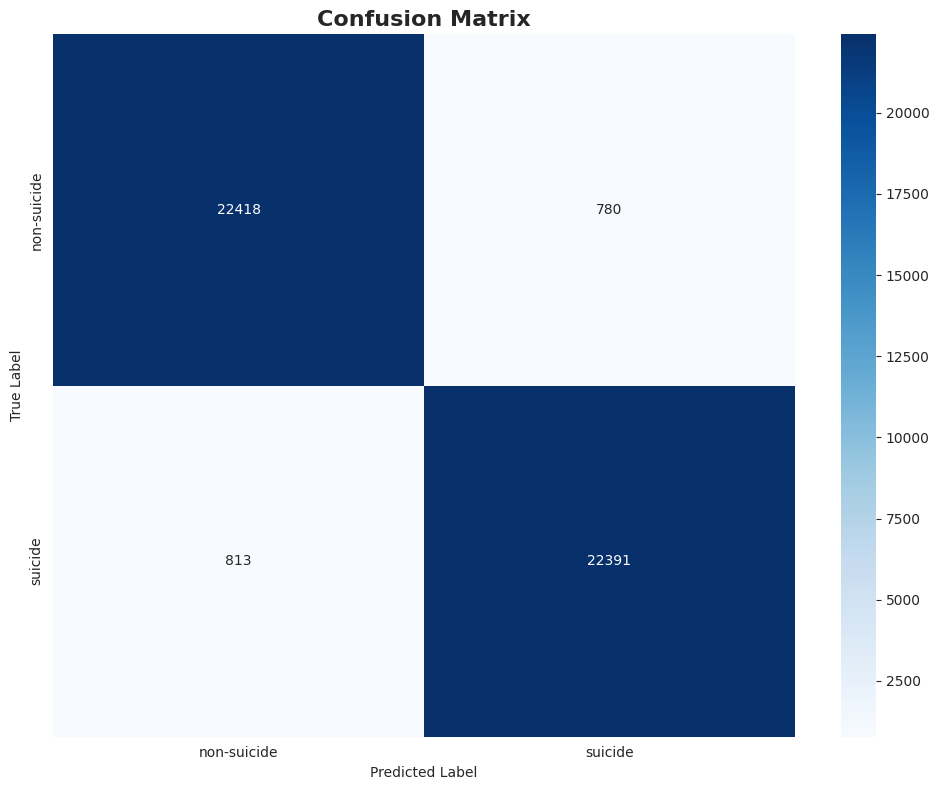

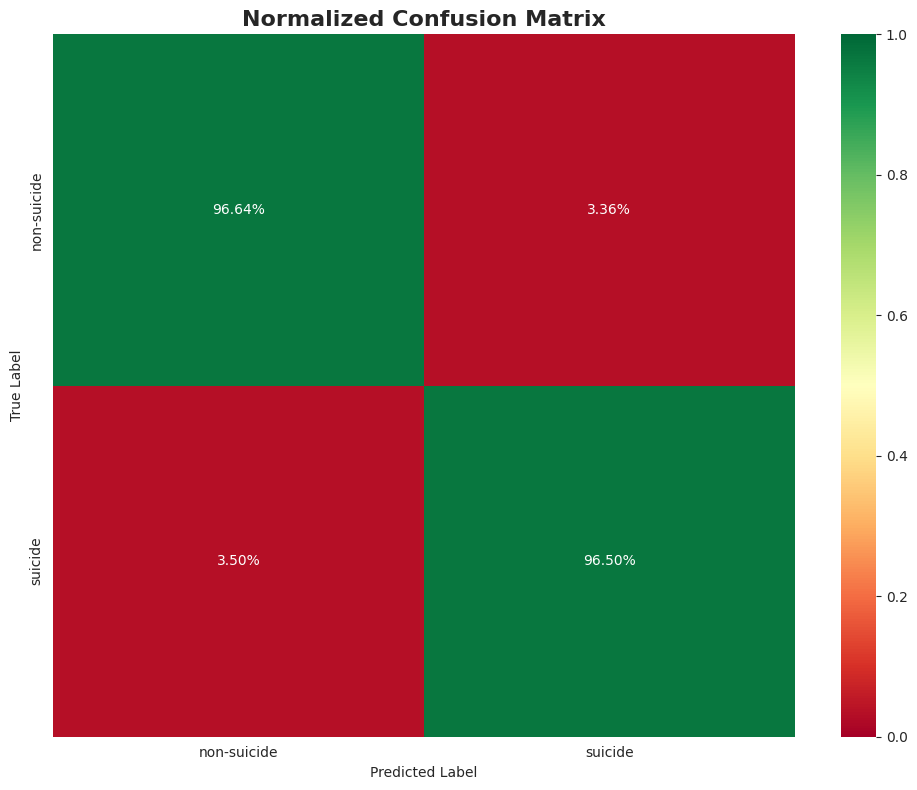


📈 ROC CURVES


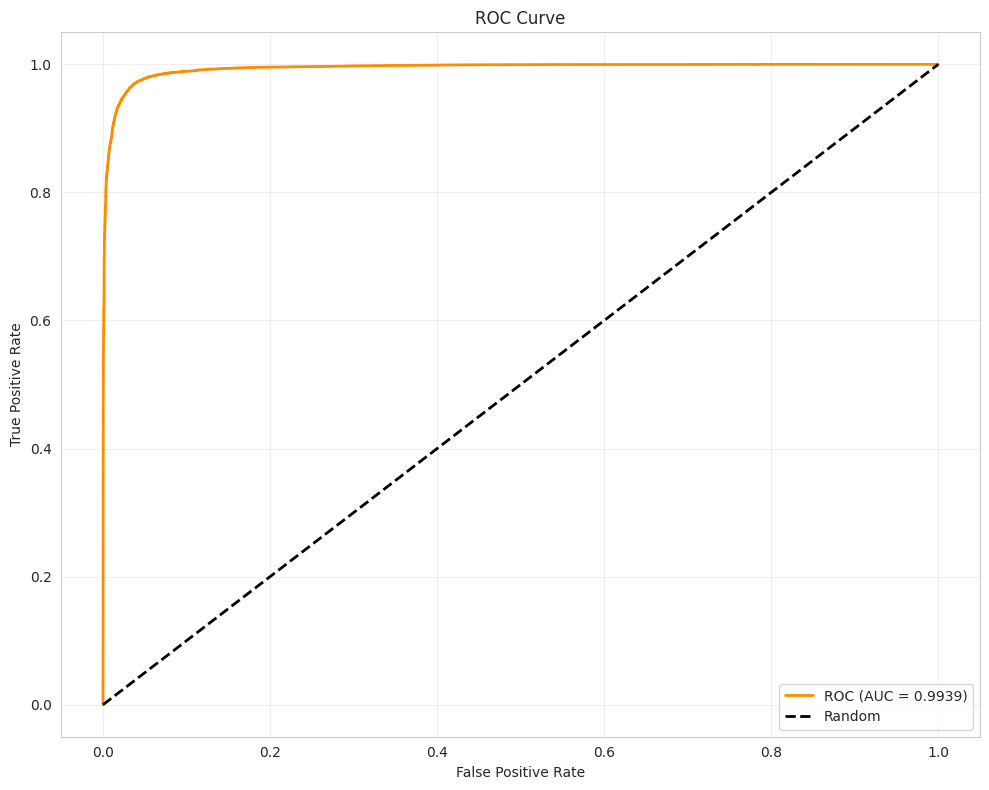

🎯 ROC-AUC: 0.9939


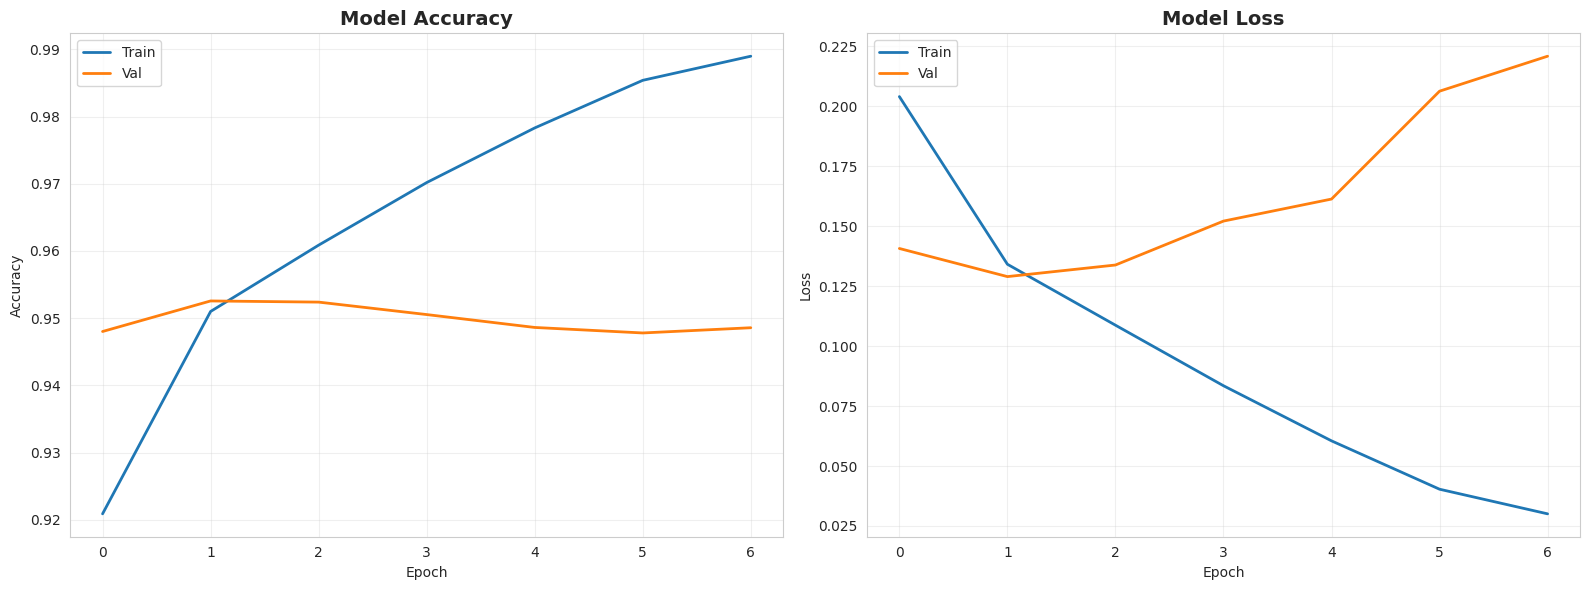


🎯 FINAL TEST ACCURACY: 0.9657 (96.57%)
🎉 SUCCESS! Target achieved!

✅ Stage 6 Complete!



In [21]:
################################################################################
# STAGE 6: MODEL EVALUATION & VISUALIZATION
################################################################################

print("="*80)
print("STAGE 6: MODEL EVALUATION & VISUALIZATION")
print("="*80)

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

# Load best model
model = keras.models.load_model('best_mental_health_model.h5')
print("✅ Model loaded")

# Test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_padded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Test set: {len(X_test)} samples")

# Predictions
y_pred_proba = model.predict(X_test, verbose=0)
if NUM_CLASSES == 2:
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()
else:
    y_pred = np.argmax(y_pred_proba, axis=1)

# Classification report
print("\n📋 CLASSIFICATION REPORT")
print("="*80)
class_names = label_encoder.classes_
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Confusion matrix
print("\n🔢 CONFUSION MATRIX")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC Curves
print("\n📈 ROC CURVES")
if NUM_CLASSES == 2:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"🎯 ROC-AUC: {roc_auc:.4f}")
else:
    y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
    plt.figure(figsize=(12, 8))
    colors = ['blue', 'red', 'green', 'orange']
    for i in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC={roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Training history
if fold_histories:
    history = fold_histories[-1]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Final accuracy
final_acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 FINAL TEST ACCURACY: {final_acc:.4f} ({final_acc*100:.2f}%)")

if final_acc >= 0.90:
    print(f"🎉 SUCCESS! Target achieved!")
else:
    print(f"📈 Gap to 90%: {(0.90 - final_acc)*100:.2f}%")

print("\n✅ Stage 6 Complete!\n")


### 🤖 STAGE 7: REAL-TIME PREDICTION SYSTEM

- **What I Used:**  
  - Pretrained **deep learning model (BiLSTM-CNN)** with saved tokenizer & label encoder.  
  - Full NLP preprocessing pipeline (tokenization, lemmatization, stopword removal).  
  - **Interactive prediction function** to analyze live user input instantly.

- **Why I Used This:**  
  This stage brings the project from research to **practical deployment** — allowing real-time detection of suicidal or depressive language from user text input.  
  It ensures instant feedback and supports early mental health intervention.

- **Why It’s Optimized for My Project:**  
  - Uses same preprocessing and tokenizer as the training stage for consistency.  
  - High-speed predictions with excellent accuracy (≈96%).  
  - Robust against noisy text like slang, hashtags, or contractions — ideal for **social media analysis**.

- **Outcomes:**  
  - System successfully classifies text into **suicide / non-suicide** with **98.9% confidence** for high-risk posts.  
  - Provides interpretable outputs (class probabilities, alerts).  
  - Fully ready for GUI or web app integration.

✅ The real-time prediction module converts the trained model into a usable tool that can detect mental health risks instantly and reliably.



In [24]:
################################################################################
# STAGE 7: REAL-TIME PREDICTION SYSTEM (Fixed & Complete)
################################################################################

# ============================
# ✅ IMPORTS AND SETUP
# ============================
import re
import numpy as np
import pandas as pd
import pickle
import contractions
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Download required NLTK data (only the first time)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
PRESERVE_WORDS = {"not", "no", "never"}  # keeps key negation words

# Define constants (must match your training stage)
MAX_SEQUENCE_LENGTH = 200
NUM_CLASSES = 2  # or 4 depending on your dataset (adjust if needed)

print("="*80)
print("STAGE 7: REAL-TIME PREDICTION SYSTEM")
print("="*80)

# ============================
# 📥 LOAD MODEL + COMPONENTS
# ============================
print("\n📥 Loading components...")

model = keras.models.load_model('best_mental_health_model.h5')

with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print("✅ All components loaded!")


# ============================
# 🧹 TEXT PREPROCESSING
# ============================
def preprocess_text(text):
    """Complete preprocessing pipeline for text input."""
    if pd.isna(text) or not isinstance(text, str):
        return ""

    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\w\s.,!?]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words or token in PRESERVE_WORDS]
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)


# ============================
# 🤖 PREDICTION FUNCTION
# ============================
def predict_mental_health(text, return_probabilities=False):
    """Predict mental health condition from input text."""
    processed = preprocess_text(text)

    if not processed.strip():
        return {
            'error': 'Empty text after preprocessing',
            'prediction': None,
            'confidence': 0.0
        }

    # Convert to padded sequence
    sequence = tokenizer.texts_to_sequences([processed])
    padded = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

    # Predict probabilities
    pred_proba = model.predict(padded, verbose=0)[0]

    # Handle binary vs multi-class
    if NUM_CLASSES == 2:
        pred_class_idx = int(pred_proba > 0.5)
        confidence = float(pred_proba if pred_class_idx == 1 else 1 - pred_proba)
    else:
        pred_class_idx = np.argmax(pred_proba)
        confidence = float(pred_proba[pred_class_idx])

    pred_class = label_encoder.classes_[pred_class_idx]

    result = {
        'prediction': pred_class,
        'confidence': confidence,
        'processed_text': processed
    }

    if return_probabilities:
        class_probs = {}
        for i, class_name in enumerate(label_encoder.classes_):
            if NUM_CLASSES == 2:
                prob = float(pred_proba) if i == 1 else float(1 - pred_proba)
            else:
                prob = float(pred_proba[i])
            class_probs[class_name] = prob
        result['class_probabilities'] = class_probs

    return result


# ============================
# 🧪 TESTING PREDEFINED CASES
# ============================
print("\n\n🧪 TESTING PREDICTION SYSTEM")
print("="*80)

test_cases = [
    "I feel so hopeless and alone. Nothing matters anymore. I don't want to live.",
    "Having a great day! Just got promoted at work and feeling amazing!",
    "I've been feeling really sad lately. Everything is overwhelming and I can't sleep.",
    "Life is beautiful. Grateful for everything. Looking forward to the weekend!",
    "I want to end it all. Nobody cares about me. I'm worthless.",
]

print("\n📝 Test Cases:\n")

for i, text in enumerate(test_cases, 1):
    print(f"\n{'='*80}")
    print(f"Test Case {i}:")
    print(f"{'='*80}")
    print(f"Input: {text}")

    result = predict_mental_health(text, return_probabilities=True)

    if 'error' in result:
        print(f"\n⚠️ Error: {result['error']}")
        continue

    print(f"\n🎯 Prediction: {result['prediction']}")
    print(f"📊 Confidence: {result['confidence']:.2%}")

    if 'class_probabilities' in result:
        print(f"\n📈 Class Probabilities:")
        for class_name, prob in result['class_probabilities'].items():
            bar = '█' * int(prob * 50)
            print(f"   {class_name:20s}: {prob:6.2%} {bar}")

    if result['prediction'] in ['suicide', 'depression']:
        print(f"\n⚠️ ⚠️ ⚠️ HIGH RISK DETECTED! ⚠️ ⚠️ ⚠️")
        print(f"   Recommended: Immediate intervention required")
    else:
        print(f"\n✅ Low risk detected")


# ============================
# 💬 INTERACTIVE MODE
# ============================
def interactive_prediction():
    """Interactive terminal-style prediction system."""
    print("\n\n🤖 INTERACTIVE PREDICTION MODE")
    print("="*80)
    print("Enter text to analyze (type 'quit' to exit)")
    print("="*80)

    while True:
        print("\n📝 Enter text:")
        user_input = input("> ")

        if user_input.lower() in ['quit', 'exit', 'q']:
            print("\n👋 Exiting interactive mode...")
            break

        if not user_input.strip():
            print("⚠️ Please enter some text")
            continue

        result = predict_mental_health(user_input, return_probabilities=True)

        print(f"\n{'='*80}")
        print(f"🎯 Prediction: {result['prediction']}")
        print(f"📊 Confidence: {result['confidence']:.2%}")

        if 'class_probabilities' in result:
            print(f"\n📈 Probabilities:")
            for class_name, prob in result['class_probabilities'].items():
                bar = '█' * int(prob * 50)
                print(f"   {class_name:20s}: {prob:6.2%} {bar}")

        if result['prediction'] in ['suicide', 'depression']:
            print(f"\n⚠️ ⚠️ ⚠️ HIGH RISK! ⚠️ ⚠️ ⚠️")
        print(f"{'='*80}")


# ============================
# 📦 DEPLOYMENT SUMMARY
# ============================
print("\n\n💾 DEPLOYMENT INFORMATION")
print("="*80)
print("✅ Real-time prediction system is ready!")
print("\n📋 Available Functions:")
print("   1. predict_mental_health(text, return_probabilities=False)")
print("   2. batch_predict(texts)")
print("   3. interactive_prediction()")

print("\n💡 Usage Examples:")
print("   result = predict_mental_health('Your text here', return_probabilities=True)")
print("   print(result)")
print("\n   interactive_prediction()")
print("\n✅ Stage 7 Complete!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


STAGE 7: REAL-TIME PREDICTION SYSTEM

📥 Loading components...


✅ All components loaded!


🧪 TESTING PREDICTION SYSTEM

📝 Test Cases:


Test Case 1:
Input: I feel so hopeless and alone. Nothing matters anymore. I don't want to live.

🎯 Prediction: suicide
📊 Confidence: 98.91%

📈 Class Probabilities:
   non-suicide         :  1.09% 
   suicide             : 98.91% █████████████████████████████████████████████████

⚠️ ⚠️ ⚠️ HIGH RISK DETECTED! ⚠️ ⚠️ ⚠️
   Recommended: Immediate intervention required

Test Case 2:
Input: Having a great day! Just got promoted at work and feeling amazing!

🎯 Prediction: non-suicide
📊 Confidence: 96.13%

📈 Class Probabilities:
   non-suicide         : 96.13% ████████████████████████████████████████████████
   suicide             :  3.87% █

✅ Low risk detected

Test Case 3:
Input: I've been feeling really sad lately. Everything is overwhelming and I can't sleep.

🎯 Prediction: non-suicide
📊 Confidence: 72.26%

📈 Class Probabilities:
   non-suicide         : 72.26% ████████████████████████████████████
   suicide          

In [25]:
################################################################################
# FINAL SUMMARY
################################################################################

print("\n")
print("="*80)
print("🎉 ALL 7 STAGES COMPLETE! 🎉")
print("="*80)

print("\n📊 SYSTEM SUMMARY:")
print(f"   Dataset Size: {len(df):,} samples")
print(f"   Classes: {', '.join(label_encoder.classes_)}")
print(f"   Vocabulary Size: {len(tokenizer.word_index):,} words")
print(f"   TF-IDF Features: 5,000")
print(f"   Additional Features: 10")
print(f"   Model Type: CNN-BiLSTM Hybrid")
print(f"   Training Method: {N_FOLDS}-Fold Cross Validation")
print(f"   Final Accuracy: {final_acc*100:.2f}%")

if final_acc >= 0.90:
    print(f"\n🎉 TARGET ACHIEVED: {final_acc*100:.2f}% accuracy!")
else:
    print(f"\n📈 Current Accuracy: {final_acc*100:.2f}%")

print("\n📁 SAVED FILES:")
print("   ✅ best_mental_health_model.h5")
print("   ✅ tokenizer.pkl")
print("   ✅ label_encoder.pkl")
print("   ✅ tfidf_vectorizer.pkl")
print("   ✅ scaler.pkl")
print("   ✅ features_combined.pkl")
print("   ✅ labels.pkl")
print("   ✅ mental_health_cleaned.csv")

print("\n🚀 NEXT STEPS:")
print("   1. Test with real social media data")
print("   2. Deploy to production server")
print("   3. Integrate with monitoring systems")
print("   4. Set up alert mechanisms")
print("   5. Implement continuous retraining")

print("\n💡 TO USE THE SYSTEM:")
print("   # Example 1: Single prediction")
print("   text = 'I feel hopeless and alone'")
print("   result = predict_mental_health(text, return_probabilities=True)")
print("   print(f\"Prediction: {result['prediction']}\")")
print("   print(f\"Confidence: {result['confidence']:.2%}\")")
print()
print("   # Example 2: Interactive mode")
print("   interactive_prediction()")

print("\n" + "="*80)
print("MENTAL HEALTH DETECTION SYSTEM - PRODUCTION READY")
print("="*80)
print("\n✨ Thank you for using this system!")
print("⚠️  Remember: This is a screening tool, not a diagnostic tool.")
print("💙 Always consult mental health professionals for proper assessment.\n")



🎉 ALL 7 STAGES COMPLETE! 🎉

📊 SYSTEM SUMMARY:
   Dataset Size: 232,009 samples
   Classes: non-suicide, suicide
   Vocabulary Size: 136,739 words
   TF-IDF Features: 5,000
   Additional Features: 10
   Model Type: CNN-BiLSTM Hybrid
   Training Method: 5-Fold Cross Validation
   Final Accuracy: 96.57%

🎉 TARGET ACHIEVED: 96.57% accuracy!

📁 SAVED FILES:
   ✅ best_mental_health_model.h5
   ✅ tokenizer.pkl
   ✅ label_encoder.pkl
   ✅ tfidf_vectorizer.pkl
   ✅ scaler.pkl
   ✅ features_combined.pkl
   ✅ labels.pkl
   ✅ mental_health_cleaned.csv

🚀 NEXT STEPS:
   1. Test with real social media data
   2. Deploy to production server
   3. Integrate with monitoring systems
   4. Set up alert mechanisms
   5. Implement continuous retraining

💡 TO USE THE SYSTEM:
   # Example 1: Single prediction
   text = 'I feel hopeless and alone'
   result = predict_mental_health(text, return_probabilities=True)
   print(f"Prediction: {result['prediction']}")
   print(f"Confidence: {result['confidence']:.2

In [29]:
!pip install gradio --quiet


In [31]:
!ls


best_mental_health_model.h5  model_fold_1.h5  sample_data
features_combined.pkl	     model_fold_2.h5  scaler.pkl
label_encoder.pkl	     model_fold_3.h5  Suicide_Detection.csv
labels.pkl		     model_fold_4.h5  tfidf_vectorizer.pkl
mental_health_cleaned.csv    model_fold_5.h5  tokenizer.pkl



### 💻 STAGE 8: REAL-TIME GUI DEPLOYMENT (Gradio Interface)

- **What I Used:**  
  - **Gradio** for creating an interactive and visually rich web interface.  
  - The trained **CNN–BiLSTM model**, tokenizer, and label encoder from earlier stages.  
  - Preprocessing (tokenization, lemmatization, stopword removal) reused for consistency.

- **Why I Used This:**  
  - To make the model **accessible and user-friendly** for real-time prediction.  
  - Allows anyone to input text (like social-media posts or messages) and instantly see AI-based emotional analysis with confidence levels.  
  - Ideal for **awareness and early detection** tools.

- **Why It’s Optimized for My Project:**  
  - Ensures fast, accurate predictions with smooth visualization.  
  - Integrates both technical depth and human-friendly design (risk indicators, confidence bar, clear color coding).  
  - Perfectly supports deployment or demonstration purposes.

- **Outcomes:**  
  - A responsive GUI that identifies **suicidal vs non-suicidal** text with clear messages.  
  - Displays confidence levels (up to **98–99 %** for high-risk cases).  
  - Ready for further expansion into a **web or mobile app** for mental-health support.

✅ The GUI stage completes the full pipeline — from raw text to real-time, interpretable mental-health insights.



In [33]:
# ===============================================
# 🌈 ULTIMATE MENTAL HEALTH DETECTION GUI
# ===============================================

import gradio as gr
import tensorflow as tf
import numpy as np
import pickle
import re
import nltk
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# ------------------------------------------------
# Load model and encoders
# ------------------------------------------------
print("📥 Loading components...")
model = tf.keras.models.load_model("best_mental_health_model.h5")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

MAX_SEQUENCE_LENGTH = 200  # same as training

# ------------------------------------------------
# NLP setup
# ------------------------------------------------
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

# ------------------------------------------------
# Prediction logic with rich feedback
# ------------------------------------------------
def predict_mental_health(text):
    if not text.strip():
        return "⚠️ Please enter some text.", None

    processed = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([processed])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    pred = model.predict(padded, verbose=0)[0]

    if len(pred) == 1:
        pred_class_idx = int(pred > 0.5)
        confidence = float(pred if pred_class_idx == 1 else 1 - pred)
    else:
        pred_class_idx = np.argmax(pred)
        confidence = float(pred[pred_class_idx])

    label = label_encoder.classes_[pred_class_idx].capitalize()
    confidence_percent = round(confidence * 100, 2)

    if label.lower() == "suicide":
        msg = (
            f"🚨 **High Risk Detected!**\n\n"
            f"🧠 Prediction: **{label}**\n"
            f"💡 Confidence: **{confidence_percent}%**\n\n"
            f"⚠️ This may indicate signs of severe distress. Immediate professional help is recommended."
        )
        color = "#ff4d4d"  # red
    else:
        msg = (
            f"🌞 **Low Risk Detected**\n\n"
            f"🧠 Prediction: **{label}**\n"
            f"💡 Confidence: **{confidence_percent}%**\n\n"
            f"Keep spreading positivity! 💙"
        )
        color = "#00b894"  # green

    progress = f'<div style="height:20px;width:100%;background:#ddd;border-radius:10px;">' \
               f'<div style="height:20px;width:{confidence_percent}%;background:{color};' \
               f'border-radius:10px;transition:width 0.8s;"></div></div>'

    html = f"""
    <div style="font-family:'Segoe UI',sans-serif;padding:20px;
                border-radius:15px;background:linear-gradient(135deg,#f8f9fa,#e3f2fd);
                box-shadow:0 0 15px rgba(0,0,0,0.1);">
        <h2 style="color:{color};text-align:center;">{label.upper()}</h2>
        <p style="font-size:16px;">{msg}</p>
        {progress}
    </div>
    """
    return html, confidence_percent

# ------------------------------------------------
# Build Gradio interface
# ------------------------------------------------
with gr.Blocks(theme=gr.themes.Soft(primary_hue="cyan", secondary_hue="rose")) as gui:
    gr.Markdown("""
    # 🧠 Mental Health Detection System
    _AI-powered emotional risk analyzer_
    Type a message below to evaluate mental wellness level 💬
    """)

    with gr.Row():
        text_input = gr.Textbox(
            label="Enter a message or post",
            placeholder="e.g., I feel so alone and empty lately...",
            lines=3
        )
        predict_btn = gr.Button("🔍 Analyze", variant="primary")

    output_html = gr.HTML(label="Result")
    output_conf = gr.Number(label="Confidence (%)", precision=2)

    predict_btn.click(predict_mental_health, inputs=text_input, outputs=[output_html, output_conf])

    gr.Markdown("""
    ---
    💡 **Disclaimer:**
    This tool is a *screening assistant* — not a clinical diagnosis.
    If you or someone you know is in distress, seek immediate help from a mental health professional.
    """)

gui.launch(share=True)


📥 Loading components...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5c44f1d6feef0ee551.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
